In [44]:
import os
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [45]:
load_dotenv()

True

In [46]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [47]:
class SentimentSchema(BaseModel):
    
    sentiment: Literal["positive", "negative", "neutral"] = Field(description='Sentiment of the review')

In [48]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [49]:
structured_model = llm.with_structured_output(SentimentSchema)
structured_model2 = llm.with_structured_output(DiagnosisSchema)

In [50]:
prompt = "What is the sentiment of the following review: The software was good but had some bugs."
structured_model.invoke(prompt).sentiment


'neutral'

In [51]:
class ReviewState(TypedDict):
    
    review: str 
    sentiment: Literal["positive", "negative", "neutral"]
    diagnosis: str 
    response: str

In [52]:
def find_sentiment(state: ReviewState):
    
    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment
    
    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive", "negative", "neutral","run_diagnosis"]:
    
    if state["sentiment"] == "positive":
        return "positive_response"
    elif state['sentiment'] == "negative":
        return "negative_response"
    elif state["sentiment"] == "neutral":
        return "neutral_response"
    else:
        return "run_diagnosis"
    
def positive_response(state: ReviewState):
    
    prompt = f"""Write a warm thank you message to the user for the following review: \n\n"{state['review']}\"\n
    Also, kindly ask them to leave feedback on our website."""
    
    response = llm.invoke(prompt).content
    
    return {'response': response}

def run_diagnosis(state: ReviewState):
    
    prompt = f"""Diagnose this negative review: \n\n{state['review']}\n"
    "Return issue_type, tone, and urgancy.
"""

    response = structured_model2.invoke(prompt)
    
    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):
    
    diagnosis = state['diagnosis']
    
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked ungency as '{diagnosis['urgancy']}'.
Write an emphathetic, helpful resolution message. 
""" 
    
    response = llm.invoke(prompt).content 
    
    return {'response': response}

In [31]:
def find_sentiment(state):
    review = state["review"]   # since you're using dict state

    if "laggy" in review.lower():
        sentiment = "negative"
    else:
        sentiment = "positive"

    return {
        "sentiment": sentiment
    }

In [53]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges(
    "find_sentiment",
    check_sentiment,
    {
        "positive": "positive_response",
        "negative": "negative_response",
        "neutral": "negative_response",   
        "run_diagnosis": "run_diagnosis",
    }
)                         

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

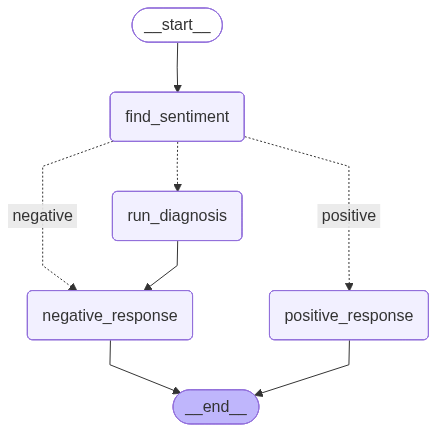

In [54]:
workflow

In [71]:
initial_state = {
    "review": "I've been using this app for about a month now, and I must say, the user interface is clean and intuitive. Everything is exactly where you'd expect it to be. It's rare to find something like that just work fine without tutorial. Great job to the design team!.",
}

llm.invoke(initial_state["review"]).content

"Thank you for your kind words about the app's user interface. However, I must clarify that this is not an app, but rather a text-based AI assistant. I don't have a design team or a physical interface, but I'm glad to hear that our conversation has been intuitive and easy to follow. I'm here to help answer your questions and provide information, so please feel free to ask me anything!"